In [208]:
#Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

In [209]:
#Generate synthetic high-dimensional dataset
from sklearn.datasets import make_classification

# Dataset 1: Well-separated classes
X, y = make_classification(
    n_samples=500,           #More samples = better generalization
    n_features=15,
    n_informative=8,         #Stronger signal
    n_redundant=0,
    n_repeated=0,
    n_classes=3,
    n_clusters_per_class=1,  #Simpler clusters
    flip_y=0.0,              #No label noise
    class_sep=1,
    random_state=42
)

print("Dataset shape:", X.shape)
print("Unique classes:", np.unique(y))

Dataset shape: (500, 15)
Unique classes: [0 1 2]


In [210]:
#Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42,stratify=y)

In [211]:
#Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**CASE A:WITHOUT LDA**

In [212]:
#Train SVM without LDA
svm_original = SVC(kernel='rbf', random_state=42)

svm_original.fit(X_train_scaled, y_train)

y_pred_original = svm_original.predict(X_test_scaled)

accuracy_original = accuracy_score(y_test, y_pred_original)

print("Accuracy WITHOUT LDA:", accuracy_original)

Accuracy WITHOUT LDA: 0.8666666666666667


In [213]:
#Compute variance before LDA
variance_before = np.var(X_train_scaled, axis=0)
total_variance_before = np.sum(variance_before)

print("Total variance BEFORE LDA:", total_variance_before)

Total variance BEFORE LDA: 15.0


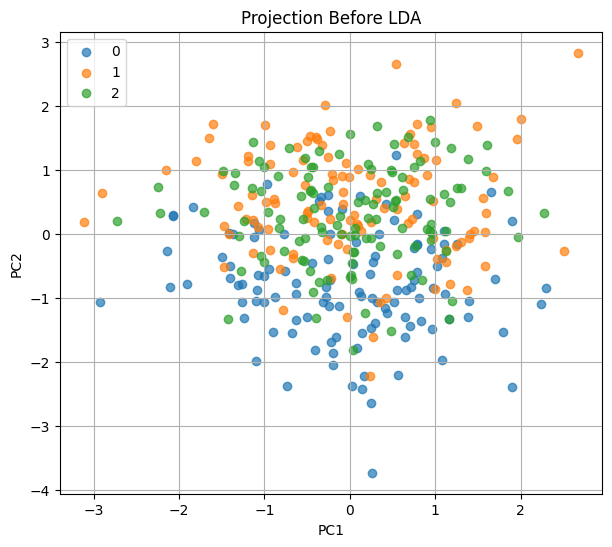

In [214]:
plt.figure(figsize=(7,6))

for cls in np.unique(y_train):
    plt.scatter(
        X_train_scaled[y_train==cls,0],
        X_train_scaled[y_train==cls,1],
        label=cls,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection Before LDA")
plt.legend()
plt.grid(True)
plt.show()

**CASE B: WITH LDA**

In [215]:
#Apply LDA
lda = LinearDiscriminantAnalysis(n_components=2)

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

print("Shape after LDA:", X_train_lda.shape)

Shape after LDA: (350, 2)


In [216]:
#Compute variance after LDA
variance_after = np.var(X_train_lda, axis=0)
total_variance_after = np.sum(variance_after)

print("Total variance AFTER LDA:", total_variance_after)
print("Explained variance ratio:", lda.explained_variance_ratio_)

Total variance AFTER LDA: 4.782857658053094
Explained variance ratio: [0.69390024 0.30609976]


In [217]:
#Train SVM after LDA
svm_lda = SVC(kernel='rbf', random_state=42)

svm_lda.fit(X_train_lda, y_train)

y_pred_lda = svm_lda.predict(X_test_lda)

accuracy_lda = accuracy_score(y_test, y_pred_lda)

print("Accuracy WITH LDA:", accuracy_lda)

Accuracy WITH LDA: 0.88


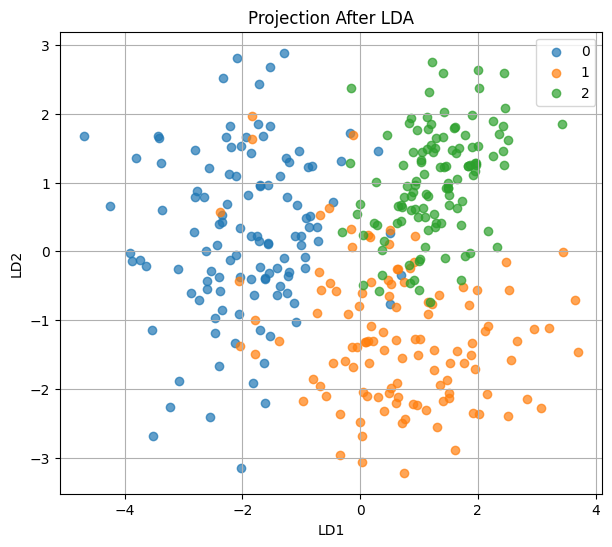

In [218]:
#Scatter plot after LDA
plt.figure(figsize=(7,6))

for cls in np.unique(y_train):
    plt.scatter(
        X_train_lda[y_train==cls,0],
        X_train_lda[y_train==cls,1],
        label=cls,
        alpha=0.7
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Projection After LDA")
plt.legend()
plt.grid(True)
plt.show()

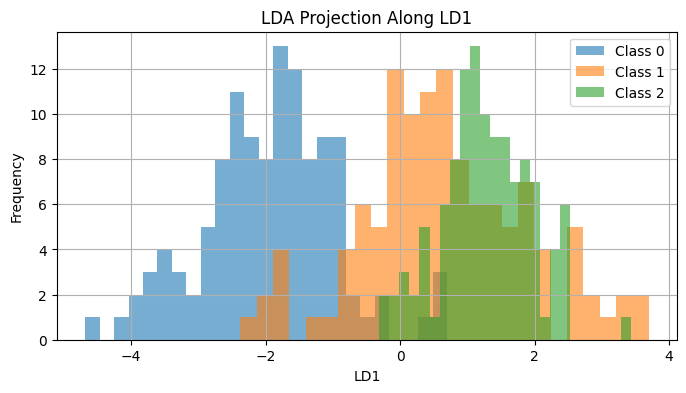

In [221]:
#Histogram along LD1
plt.figure(figsize=(8,4))

for cls in np.unique(y_train):
    plt.hist(
        X_train_lda[y_train==cls,0],
        bins=25,
        alpha=0.6,
        label=f"Class {cls}"
    )

plt.xlabel("LD1")
plt.ylabel("Frequency")
plt.title("LDA Projection Along LD1")
plt.legend()
plt.grid(True)
plt.show()

In [219]:
#Compare results
print("\n==========FINAL COMPARISON==========")

print("\n---Accuracy Comparison---")
print("Accuracy without LDA:", accuracy_original)
print("Accuracy with LDA:", accuracy_lda)

print("\n---Dimensionality---")
print("Number of features before LDA:", X_train_scaled.shape[1])
print("Number of features after LDA:", X_train_lda.shape[1])

print("\n---Variance Comparison---")
print("Total variance BEFORE LDA:", total_variance_before)
print("Total variance AFTER LDA:", total_variance_after)

print("\n---LDA Explained Variance Ratio---")
print("Explained variance ratio:", lda.explained_variance_ratio_)


==========FINAL COMPARISON==========

---Accuracy Comparison---
Accuracy without LDA: 0.8666666666666667
Accuracy with LDA: 0.88

---Dimensionality---
Number of features before LDA: 15
Number of features after LDA: 2

---Variance Comparison---
Total variance BEFORE LDA: 15.0
Total variance AFTER LDA: 4.782857658053094

---LDA Explained Variance Ratio---
Explained variance ratio: [0.69390024 0.30609976]
